In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from torch.utils.data import Dataset, DataLoader
from source.model.memory import HebbianMemory
from source.utils import get_sequence, DatasetConverter
import matplotlib.pyplot as plt

In [16]:
torch.manual_seed(0)
random.seed(0)

n_members = 7
vocab_size = 2*n_members + 1
seq_len = 3
hidden_size = 60
num_epochs = 100
total_samples = 100

model = HebbianMemory(vocab_size=vocab_size,hidden_size=hidden_size)

sequence = get_sequence(total_samples, 2, n_members, train_percent=1.0)
dataset = DatasetConverter(sequence, short_term_memory=1)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

hidden_codes = []
total = 0
for x,y in loader:
    _, h = model(x)

    total += 1
    if total > 20:
        hidden_codes.append(h.squeeze(0).numpy())


hidden_codes = torch.tensor(hidden_codes)

/var/folders/_7/jy1bxm8x25zgqldfzz7cqv8r0000gn/T/ipykernel_19410/1579399574.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/torch/csrc/utils/tensor_new.cpp:281.)
  hidden_codes = torch.tensor(hidden_codes)


In [17]:
hidden_codes

tensor([[-0.4234, -0.4752, -0.2997,  ...,  0.4495,  0.9944, -0.8899],
        [ 0.4960, -0.3880,  0.3760,  ..., -0.4585,  0.3886, -0.4522],
        [ 0.0912,  0.9569,  0.7726,  ...,  0.9712, -0.4091,  0.6684],
        ...,
        [ 0.6151, -0.6110,  0.0381,  ..., -0.5220, -0.0844, -0.6727],
        [-0.8365, -0.8503, -0.1085,  ...,  0.5656,  0.8982,  0.9973],
        [ 0.6931, -0.0560,  0.6627,  ...,  0.6612, -0.7546,  0.8980]])

In [8]:
dataset[0][0].unsqueeze(1)

tensor([[2]])

tensor([[1, 2, 0]])
tensor([[2, 0, 6]])
tensor([[0, 6, 4]])
tensor([[6, 4, 5]])
tensor([[4, 5, 3]])
tensor([[5, 3, 6]])
tensor([[3, 6, 5]])
tensor([[6, 5, 3]])
tensor([[5, 3, 4]])
tensor([[3, 4, 6]])
tensor([[4, 6, 0]])
tensor([[6, 0, 2]])
tensor([[0, 2, 1]])
tensor([[2, 1, 6]])
tensor([[1, 6, 5]])
tensor([[6, 5, 3]])
tensor([[5, 3, 4]])
tensor([[3, 4, 6]])
MDS stress: 3258.450080966544


/var/folders/_7/jy1bxm8x25zgqldfzz7cqv8r0000gn/T/ipykernel_94165/4010295038.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/torch/csrc/utils/tensor_new.cpp:281.)
  hidden_codes = torch.tensor(hidden_codes)


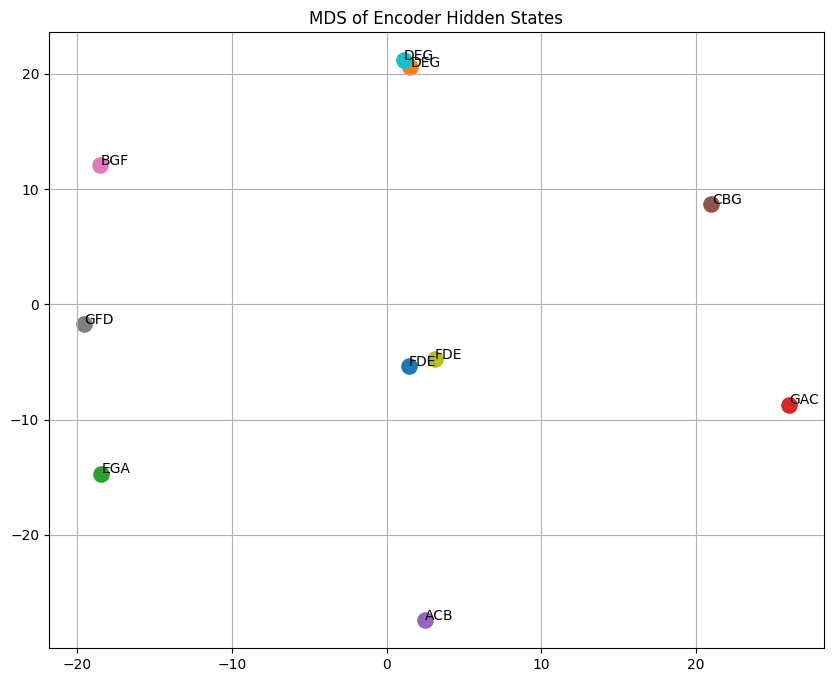

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import itertools

# Step 1: Generate the sequence
sequence = get_sequence(22, 2, 3, train_percent=1.0)
dataset = DatasetConverter(sequence)
loader = DataLoader(dataset, batch_size=1, shuffle=False)
# Step 2–3: Run through encoder and collect hidden states
hidden_codes = []
labels = []

h = None
total = 0
model.eval()
with torch.no_grad():
    for x, y in loader:
        total += 1
        print(x)
        _, h, _ = model(x, h)

        if total>8:
            hidden_codes.append(h.squeeze(0,1).numpy())  # extract (H,) from (1,1,H)

            s = ''
            for d in x[0]:
                s += chr(d+ord('A'))
            labels.append(s)

# Step 4: Reduce dimension
hidden_codes = torch.tensor(hidden_codes)
# Step 1: MDS projection
mds = MDS(
    n_components=2,
    random_state=420,
    dissimilarity="euclidean",  # uses Euclidean distances on hidden_codes
    normalized_stress="auto"
)

embeddings = mds.fit_transform(hidden_codes)

# Optional: report stress (lower is better)
print("MDS stress:", mds.stress_)

# Step 2: Plot
plt.figure(figsize=(10, 8))
for i, txt in enumerate(labels):
    plt.scatter(embeddings[i, 0], embeddings[i, 1], s=120)
    plt.text(
        embeddings[i, 0] + 0.02,
        embeddings[i, 1] + 0.02,
        txt,
        fontsize=10
    )

plt.title("MDS of Encoder Hidden States")
plt.grid(True)
plt.show()


In [4]:
hidden_codes

tensor([[2.4586e-01, 1.0227e+01, 9.0262e+00, 7.7091e+00, 0.0000e+00, 0.0000e+00,
         4.5165e+00, 9.2668e+00, 0.0000e+00, 1.2709e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 3.8554e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 4.2965e+00,
         2.7169e-01, 6.8444e-01, 0.0000e+00, 1.4916e+00, 1.6428e+01, 0.0000e+00,
         1.8659e+00, 5.3134e+00, 0.0000e+00, 7.2139e+00, 0.0000e+00, 5.4037e+00,
         1.0314e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 6.4282e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 8.3122e-01, 0.0000e+00,
         2.7540e+00, 1.1541e+01, 1.0683e+00, 1.5322e+00, 4.0285e+00, 4.0146e+00,
         3.4144e+00, 7.5046e-01, 6.8916e+00, 4.7926e+00, 5.5523e+00, 0.0000e+00,
         8.2525e+00, 6.0121e+00, 1.1517e+01, 6.0499e+00, 3.7259e+00, 0.0000e+00],
        [0.0000e+00, 8.4883e+00, 6.1040e+00, 3.5314e+00, 0.0000e+00, 0.0000e+00,
         3.5649e+00, 9.9542e+00, 1.8302e+00, 6.3242e+00, 5.4712e+00, 4.2127e+00,
         2.0838e+00, 5.1293

In [13]:
hidden_codes[:,3]

tensor([ 0.9352, -0.9419, -0.9897, -0.6680, -0.9635, -0.5917,  0.1616, -0.1398,
         0.9468, -0.9511])

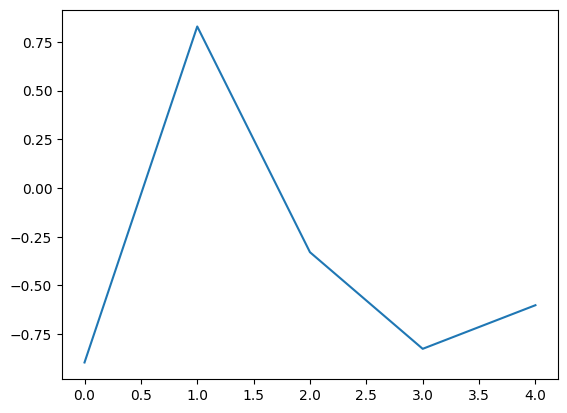

In [22]:
import numpy as np 

plt.plot(hidden_codes[:,3][:5])

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Example: 100 hidden states of dimension 30
# Replace this with your actual tensor
hidden_states = hidden_codes

# Parameters
window_size = 3
num_states, D = hidden_states.shape

# Prepare sliding window dataset
X = []
Y = []
for t in range(window_size, num_states):
    # concatenate last 3 hidden states
    x_window = hidden_states[t-window_size:t].reshape(-1)  # shape: 3*D
    y_target = hidden_states[t]  # next hidden state
    X.append(x_window)
    Y.append(y_target)

X = torch.stack(X)  # shape: (num_states - window_size, 3*D)
Y = torch.stack(Y)  # shape: (num_states - window_size, D)

# Linear predictor
class LinearPredictor(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

model = LinearPredictor(input_dim=window_size*D, output_dim=D)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Training loop
for epoch in range(500):  # can reduce/increase epochs
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, MSE Loss: {loss.item():.6f}")

# Evaluate cosine similarity per state
with torch.no_grad():
    Y_pred = model(X)
    cos_sim = F.cosine_similarity(Y_pred, Y, dim=1)
    print(f"Average cosine similarity: {cos_sim.mean():.4f}")


Epoch 0, MSE Loss: 0.740841
Epoch 50, MSE Loss: 0.001174
Epoch 100, MSE Loss: 0.000007
Epoch 150, MSE Loss: 0.000000
Epoch 200, MSE Loss: 0.000031
Epoch 250, MSE Loss: 0.000001
Epoch 300, MSE Loss: 0.000000
Epoch 350, MSE Loss: 0.000023
Epoch 400, MSE Loss: 0.000039
Epoch 450, MSE Loss: 0.000002
Average cosine similarity: 1.0000


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Suppose hidden_states is your original tensor: shape (100, D)
hidden_states = hidden_codes  # replace with your actual tensor
D = hidden_states.shape[1]

# --- Step 1: Downsample by 3 ---
hidden_downsampled = hidden_states[::3]  # take every 3rd state
num_states_down = hidden_downsampled.shape[0]

# Parameters
window_size = 3  # last 3 states to predict next

# --- Step 2: Prepare sliding window dataset ---
X = []
Y = []
for t in range(window_size, num_states_down):
    x_window = hidden_downsampled[t-window_size:t].reshape(-1)  # shape: 3*D
    y_target = hidden_downsampled[t]  # next state
    X.append(x_window)
    Y.append(y_target)

X = torch.stack(X)  # shape: (num_states_down - window_size, 3*D)
Y = torch.stack(Y)  # shape: (num_states_down - window_size, D)

# --- Step 3: Linear predictor ---
class LinearPredictor(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

model = LinearPredictor(input_dim=window_size*D, output_dim=D)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# --- Step 4: Training loop ---
for epoch in range(500):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, MSE Loss: {loss.item():.6f}")

# --- Step 5: Evaluate cosine similarity ---
with torch.no_grad():
    Y_pred = model(X)
    cos_sim = F.cosine_similarity(Y_pred, Y, dim=1)
    print(f"Average cosine similarity (downsampled): {cos_sim.mean():.4f}")


Epoch 0, MSE Loss: 0.954898
Epoch 50, MSE Loss: 0.002192
Epoch 100, MSE Loss: 0.000015
Epoch 150, MSE Loss: 0.000000
Epoch 200, MSE Loss: 0.000000
Epoch 250, MSE Loss: 0.000000
Epoch 300, MSE Loss: 0.000000
Epoch 350, MSE Loss: 0.000000
Epoch 400, MSE Loss: 0.000000
Epoch 450, MSE Loss: 0.000000
Average cosine similarity (downsampled): 1.0000


In [31]:
torch.manual_seed(10)
random.seed(10)

vocab_size = 10
seq_len = 3
hidden_size = 30
num_epochs = 1000
total_samples = 1000

model = MemoryContinuous(
    input_size=vocab_size,
    hidden_size=hidden_size,
    embedding_dim=3,
    tau=.1
)

sequence = generate_seq(total_samples, vocab_size)
dataset = DatasetConverter(sequence)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

lambda_cont = 1   # continuity strength

h = None
h_prev = None   # store previous hidden state
hidden_codes_prev = None
dis = []
for epoch in range(num_epochs):
    for x in loader:
        logits, h_ = model(x, h)

        # -------- reconstruction loss --------
        #print(logits[:, 2], x[:, seq_len-2-1])
        recon_loss = sum(
            criterion(logits[:, t], x[:, seq_len-t-1]) for t in range(seq_len)
        ) / seq_len

        # -------- continuity regularizer --------
        if h_prev is None:
            cont_loss = torch.tensor(0.0, device=logits.device)
        else:
            cont_loss = torch.mean((h_ - h_prev) ** 2)

        loss = recon_loss + lambda_cont * cont_loss

        if loss > 1e-2:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # update hidden states
        h_prev = h_.detach()
        h = h_.detach()
    

    sequence_test = generate_seq(vocab_size+12, vocab_size)
    dataset_test = DatasetConverter(sequence_test)
    loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)
    # Step 2–3: Run through encoder and collect hidden states
    hidden_codes = []
    labels = []

    ht = None
    total = 0

    with torch.no_grad():
        for x in loader_test:
            total += 1
            _, ht = model(x, ht)

            if total>8:
                hidden_codes.append(ht[0].numpy())  # extract (H,) from (1,1,H)

    # Step 4: Reduce dimension
    hidden_codes = torch.tensor(hidden_codes)

    if hidden_codes_prev != None:
        dis.append(
            torch.mean(torch.abs((hidden_codes - hidden_codes_prev)))
        )
    
    hidden_codes_prev = hidden_codes.clone()

    print(
        f"Epoch {epoch}: "
        f"recon={recon_loss.item():.4f}, "
        f"cont={cont_loss.item():.4f}"
    )


NameError: name 'generate_seq' is not defined

Text(0, 0.5, 'Hidden State Drift')

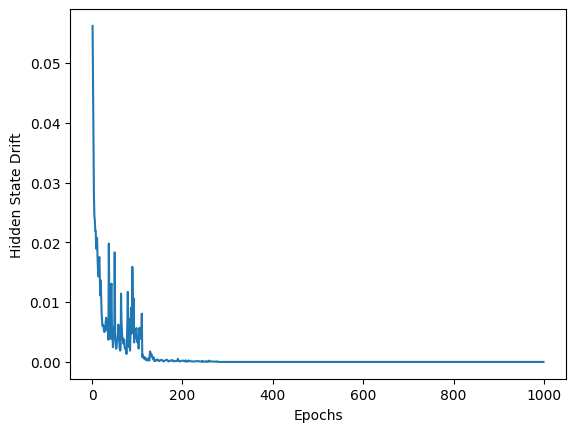

In [124]:
plt.plot(np.arange(1,num_epochs),dis)
plt.xlabel('Epochs')
plt.ylabel('Hidden State Drift')